# TT-19 — XGBoost Regressor: Dự báo nhu cầu thuê xe đạp theo giờ

In [2]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from features import (
    load_data, prove_leakage, drop_leaky_columns,
    time_based_split, add_cyclical_features,
    naive_weekly_baseline, evaluate,
)

DATA_PATH = '../dataset/hour.csv'

## Bước 1–2: Nạp dữ liệu và CHỨNG MINH RÒ RỈ

`cnt = casual + registered` — nếu giữ 2 cột này, R² sẽ ~1.0. Chạy ô dưới để tự thấy điều đó trước khi loại bỏ.

In [3]:
df_raw = load_data(DATA_PATH)
df_raw.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [4]:
leak_result = prove_leakage(df_raw)
leak_result

{'leak_columns_used': ['casual', 'registered'],
 'r2_with_leak': 0.9976245164871216,
 'rmse_with_leak': 10.746157292046778}

**Nhận xét:** R² đạt gần 1.0 vì `cnt` là tổng đại số của `casual` và `registered`, không phải một mối quan hệ được học từ dữ liệu thực tế — đây là rò rỉ tuyệt đối, phải loại bỏ 2 cột này trước khi train model dự báo thật.

In [5]:
df = drop_leaky_columns(df_raw)
df.shape

(17379, 15)

## Bước 4: EDA nhanh

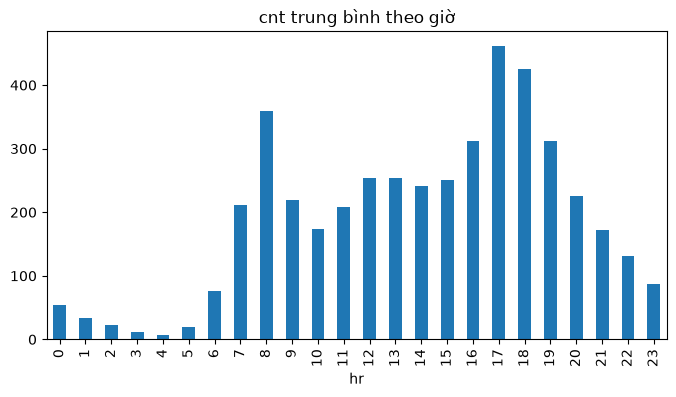

In [6]:
hourly_avg = df.groupby('hr')['cnt'].mean()
hourly_avg.plot(kind='bar', figsize=(8,4), title='cnt trung bình theo giờ')
plt.show()

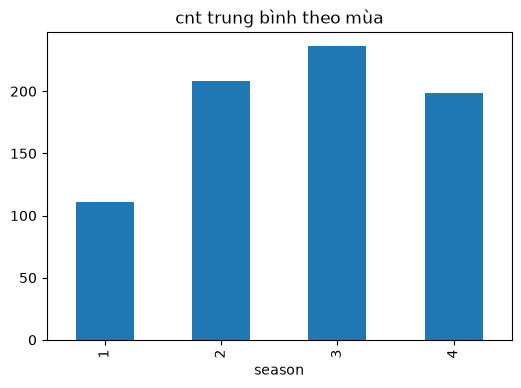

In [7]:
df.groupby('season')['cnt'].mean().plot(kind='bar', figsize=(6,4), title='cnt trung bình theo mùa')
plt.show()

## Bước 3: Chia dữ liệu THEO THỜI GIAN (không shuffle)

In [8]:
train_df, val_df, test_df = time_based_split(df)
print(len(train_df), len(val_df), len(test_df))

8645 6566 2168


## Bước 5: Mã hoá chu kỳ sin/cos

In [9]:
train_df = add_cyclical_features(train_df)
val_df = add_cyclical_features(val_df)
test_df = add_cyclical_features(test_df)

feature_cols = [c for c in train_df.columns if c not in ['cnt', 'dteday', 'instant']]
X_train, y_train = train_df[feature_cols], train_df['cnt']
X_val, y_val = val_df[feature_cols], val_df['cnt']
X_test, y_test = test_df[feature_cols], test_df['cnt']

## Bước 6: Baseline naive — cùng giờ tuần trước

In [10]:
df_lag = df.copy()
df_lag['baseline_pred'] = naive_weekly_baseline(df_lag)
baseline_test = df_lag.loc[test_df.index, 'baseline_pred']
mask = baseline_test.notna()
_ = evaluate(y_test[mask], baseline_test[mask], label='Baseline naive')

[Baseline naive] RMSE = 156.79 | R^2 = 0.3951


## Bước 7–8: Train XGBoost (raw vs log1p)

In [11]:
from xgboost import XGBRegressor

def train_xgb(Xtr, ytr, Xv, yv, **overrides):
    params = dict(
        n_estimators=2000, learning_rate=0.03, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        reg_lambda=1.0, reg_alpha=0.1, min_child_weight=3,
        objective='reg:squarederror', early_stopping_rounds=100,
        eval_metric='rmse', tree_method='hist', n_jobs=-1, random_state=42,
    )
    params.update(overrides)
    model = XGBRegressor(**params)
    model.fit(Xtr, ytr, eval_set=[(Xv, yv)], verbose=200)
    return model

model_plain = train_xgb(X_train, y_train, X_val, y_val)
pred_plain = np.clip(model_plain.predict(X_test), 0, None)
_ = evaluate(y_test, pred_plain, label='XGBoost raw')

[0]	validation_0-rmse:228.60114
[200]	validation_0-rmse:128.60413
[400]	validation_0-rmse:126.56042
[600]	validation_0-rmse:126.22034
[800]	validation_0-rmse:126.02874
[1000]	validation_0-rmse:125.82161
[1200]	validation_0-rmse:125.72815
[1400]	validation_0-rmse:125.67247
[1600]	validation_0-rmse:125.61719
[1691]	validation_0-rmse:125.63808
[XGBoost raw] RMSE = 118.63 | R^2 = 0.6537


In [12]:
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)
model_log = train_xgb(X_train, y_train_log, X_val, y_val_log)
pred_log = np.clip(np.expm1(model_log.predict(X_test)), 0, None)
_ = evaluate(y_test, pred_log, label='XGBoost log1p')

[0]	validation_0-rmse:1.47562
[200]	validation_0-rmse:0.58968
[387]	validation_0-rmse:0.58860
[XGBoost log1p] RMSE = 126.38 | R^2 = 0.6070


So sánh RMSE của 2 cách trên — chọn model tốt hơn để dùng cho các bước sau. So sánh cả hai với baseline: nếu XGBoost không thắng baseline, cần quay lại xem feature/tuning.

## Bước 9: Tuning với RandomizedSearchCV + TimeSeriesSplit

In [13]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

param_dist = {
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5, 7],
}
search = RandomizedSearchCV(
    XGBRegressor(n_estimators=500, tree_method='hist', random_state=42),
    param_distributions=param_dist, n_iter=25,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='neg_root_mean_squared_error', n_jobs=-1,
)
search.fit(X_train, y_train)
search.best_params_

{'subsample': 0.8,
 'min_child_weight': 3,
 'max_depth': 5,
 'learning_rate': 0.03,
 'colsample_bytree': 0.6}

## Bước 10: Feature importance + SHAP

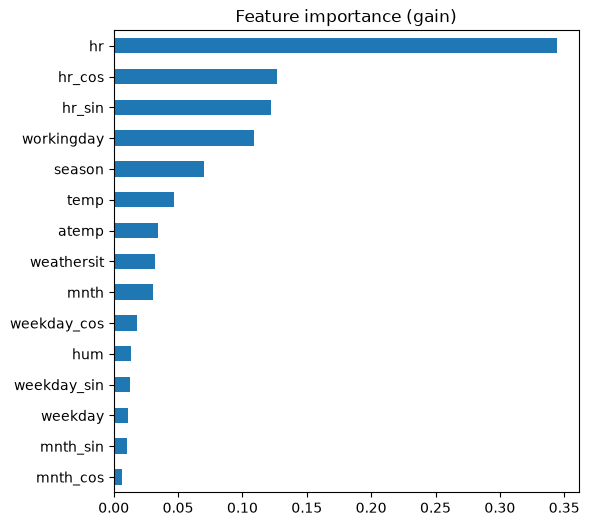

In [14]:
best_model = model_log  # đổi thành model_plain nếu RMSE raw thấp hơn
importance = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
importance.head(15).plot(kind='barh', figsize=(6,6))
plt.gca().invert_yaxis()
plt.title('Feature importance (gain)')
plt.show()

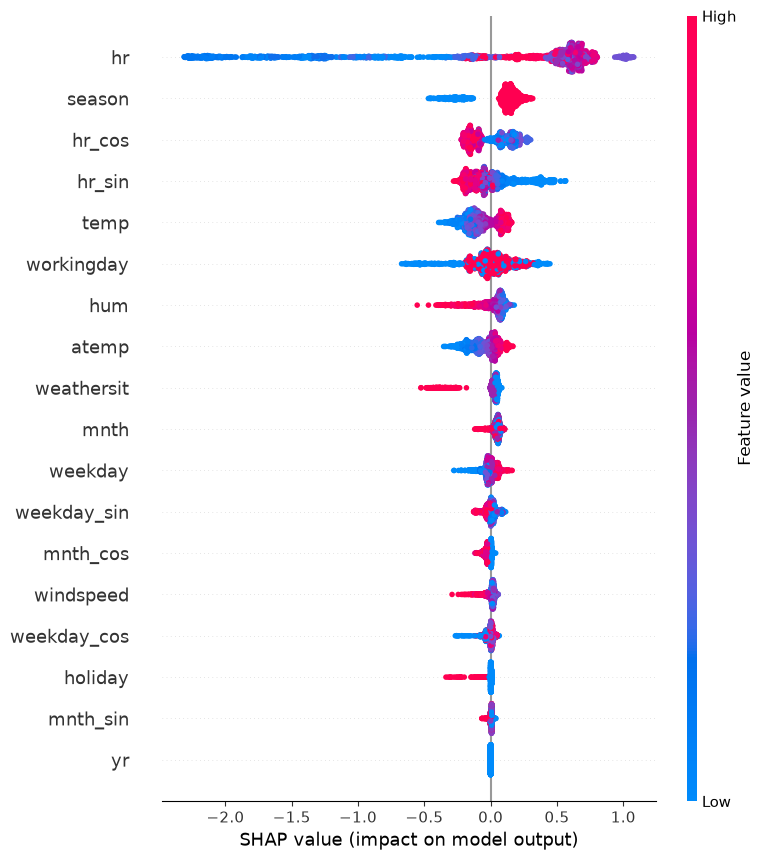

In [15]:
import shap
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

## Bước 11: Dự báo vs thực tế — 2 tuần cuối

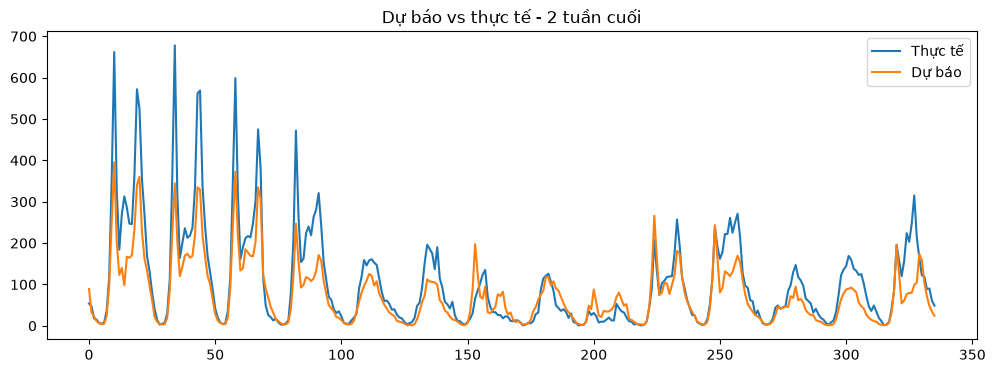

In [16]:
best_pred = pred_log  # đổi tương ứng với best_model
last_2w_idx = test_df.tail(24*14).index
plt.figure(figsize=(12,4))
plt.plot(test_df.loc[last_2w_idx, 'cnt'].values, label='Thực tế')
plt.plot(pd.Series(best_pred, index=test_df.index).loc[last_2w_idx].values, label='Dự báo')
plt.legend()
plt.title('Dự báo vs thực tế - 2 tuần cuối')
plt.show()

## Bước 12: Phân tích lỗi theo giờ / thời tiết

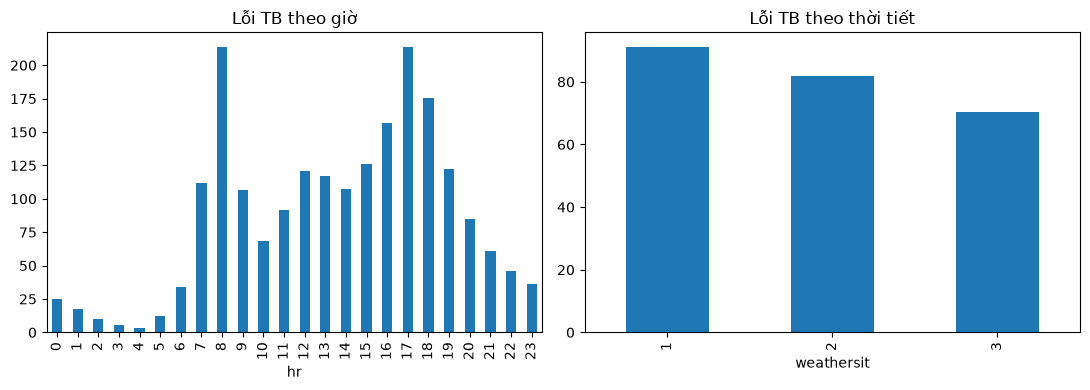

In [17]:
err_df = test_df.copy()
err_df['pred'] = best_pred
err_df['abs_err'] = (err_df['cnt'] - err_df['pred']).abs()

fig, axes = plt.subplots(1, 2, figsize=(11,4))
err_df.groupby('hr')['abs_err'].mean().plot(kind='bar', ax=axes[0], title='Lỗi TB theo giờ')
err_df.groupby('weathersit')['abs_err'].mean().plot(kind='bar', ax=axes[1], title='Lỗi TB theo thời tiết')
plt.tight_layout()
plt.show()